<a href="https://colab.research.google.com/github/claryfsz/caseNPS/blob/main/analise_NPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## libs

import pandas as pd
import numpy as np

## libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
## lendo csv
df = pd.read_csv("/desafio_nps_fase_1.csv")
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
## renomeando as colunas
df = df.rename(columns={
    'customer_id': 'id_cliente',
    'customer_age': 'idade_cliente',
    'customer_region': 'regiao_cliente',
    'customer_tenure_months': 'tempo_relacionamento_cliente_meses',
    'order_id': 'id_pedido',
    'order_value': 'vl_pedido',
    'items_quantity': 'qt_itens',
    'discount_value': 'vl_desconto',
    'payment_installments': 'nr_parcelas',
    'delivery_time_days': 'tempo_entrega_dias',
    'delivery_delay_days': 'atraso_entrega_dias',
    'freight_value': 'vl_frete',
    'delivery_attempts': 'nr_tentativas_entrega',
    'customer_service_contacts': 'nr_contatos_suporte',
    'resolution_time_days': 'tempo_resolucao_dias',
    'nps_score': 'nps',
    'repeat_purchase_30d': 'recompra_30d',
    'complaints_count': 'nr_reclamacoes',
    'csat_internal_score': 'csat_interno'
})

Tamanho da Base de Dados

In [ ]:
df.shape

(2500, 19)

In [ ]:
print(f'Tamanho do nosso Dataset (Linhas, Colunas): {df.shape}')

Tamanho do nosso Dataset (Linhas, Colunas): (2500, 19)


Verificar os tipos do Dados

In [ ]:
df.dtypes

,0
id_cliente,int64
idade_cliente,int64
regiao_cliente,object
tempo_relacionamento_cliente_meses,int64
id_pedido,int64
vl_pedido,float64
qt_itens,int64
vl_desconto,float64
nr_parcelas,int64
tempo_entrega_dias,int64


Verificando se existe valores nulos

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
print(f'Quantidade de dados nulos no nosso dataframe (base de dados): {df.isnull().sum().sum()}')

Quantidade de dados nulos no nosso dataframe (base de dados): 0


Dando inicio as analises


In [ ]:
## vamos puxar todas as colunas para melhor visualização de possiveis analises
df.columns

Index(['id_cliente', 'idade_cliente', 'regiao_cliente',
       'tempo_relacionamento_cliente_meses', 'id_pedido', 'vl_pedido',
       'qt_itens', 'vl_desconto', 'nr_parcelas', 'tempo_entrega_dias',
       'atraso_entrega_dias', 'vl_frete', 'nr_tentativas_entrega',
       'nr_contatos_suporte', 'tempo_resolucao_dias', 'nps', 'recompra_30d',
       'nr_reclamacoes', 'csat_interno'],
      dtype='object')

In [ ]:
## classificando as categorias do NPS
def classificar_nps(score):
    if score >= 9:
        return 'promotor'
    elif score >= 7:
        return 'neutro'
    else:
        return 'detrator'

df['categoria_nps'] = df['nps'].apply(classificar_nps)

In [ ]:
## separando colunas relevantes para analise
df_nps = df[['vl_pedido', 'qt_itens', 'vl_desconto', 'nr_parcelas', 'tempo_entrega_dias', 'atraso_entrega_dias',
             'vl_frete', 'nr_tentativas_entrega', 'nr_contatos_suporte', 'tempo_resolucao_dias', 'nps',
             'categoria_nps', 'recompra_30d', 'nr_reclamacoes', 'csat_interno']]

In [ ]:
## estatistica descritiva
df_nps.describe().round(2)

,vl_pedido,qt_itens,vl_desconto,nr_parcelas,tempo_entrega_dias,atraso_entrega_dias,vl_frete,nr_tentativas_entrega,nr_contatos_suporte,tempo_resolucao_dias,nps,recompra_30d,nr_reclamacoes,csat_interno
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


- primeiro vamos identificar o ponto crítico para a satisfação do cliente

In [ ]:
## analisando qual a media de cada coluna de acordo com a categoria do NPS
df_nps_agrupado = df_nps.groupby('categoria_nps').mean(numeric_only=True)
df_nps_agrupado

,vl_pedido,qt_itens,vl_desconto,nr_parcelas,tempo_entrega_dias,atraso_entrega_dias,vl_frete,nr_tentativas_entrega,nr_contatos_suporte,tempo_resolucao_dias,nps,recompra_30d,nr_reclamacoes,csat_interno
categoria_nps,,,,,,,,,,,,,,
detrator,429.309540,3.483167,29.442684,5.977715,7.994310,2.414889,38.298326,1.997155,1.632053,5.694642,3.651778,0.000000,4.442390,2.536036
neutro,458.171779,3.313167,30.843025,6.277580,8.263345,1.053381,38.063381,2.010676,1.007117,4.615658,7.787189,0.384342,2.693950,4.773665
promotor,468.084182,3.636364,32.750364,5.809091,7.936364,0.718182,37.050545,2.154545,0.672727,3.700000,9.606364,1.000000,2.272727,6.037273


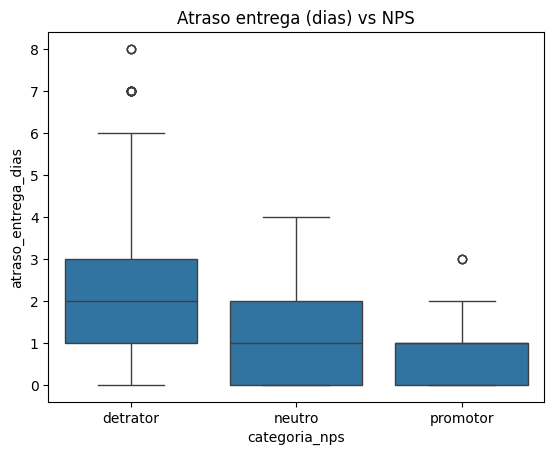

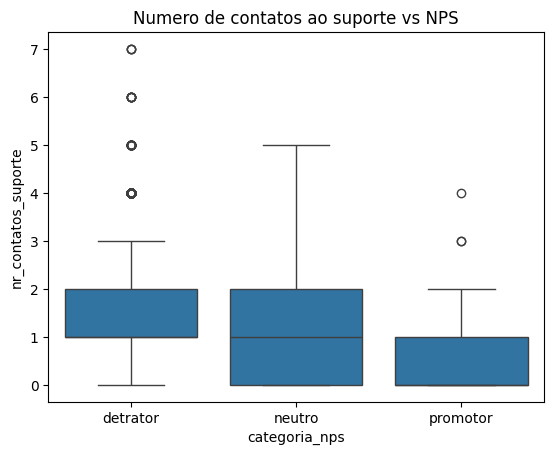

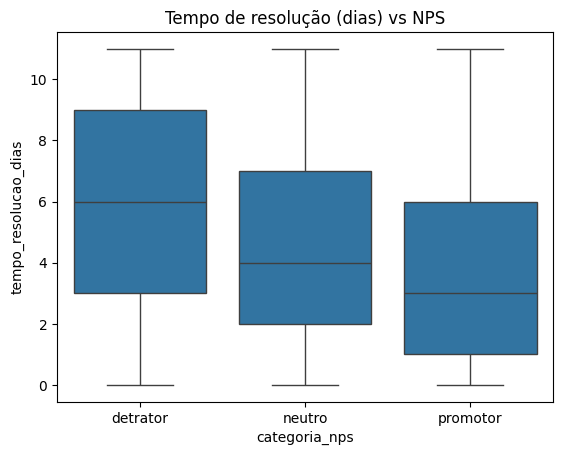

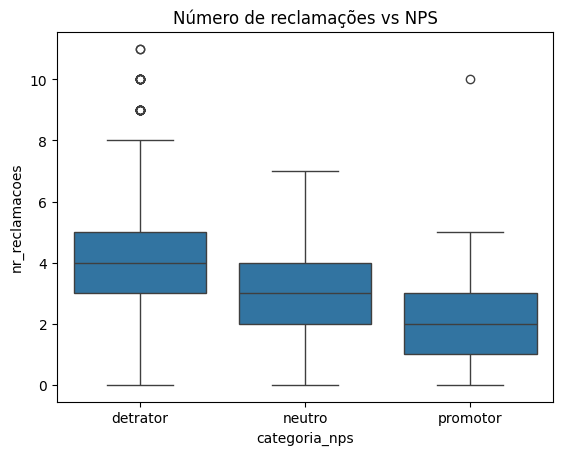

In [ ]:
## agora vamos entender como cada variavel se comporta entre cada categoria do NPS
# - atraso_entrega_dias
plt.figure()
sns.boxplot(data=df_nps, x='categoria_nps', y='atraso_entrega_dias')
plt.title(f'Atraso entrega (dias) vs NPS')
plt.show()
# - nr_contatos_suporte
plt.figure()
sns.boxplot(data=df_nps, x='categoria_nps', y='nr_contatos_suporte')
plt.title(f'Numero de contatos ao suporte vs NPS')
plt.show()
# - tempo_resolucao_dias
plt.figure()
sns.boxplot(data=df_nps, x='categoria_nps', y='tempo_resolucao_dias')
plt.title(f'Tempo de resolução (dias) vs NPS')
plt.show()
# - nr_reclamacoes
plt.figure()
sns.boxplot(data=df_nps, x='categoria_nps', y='nr_reclamacoes')
plt.title(f'Número de reclamações vs NPS')
plt.show()

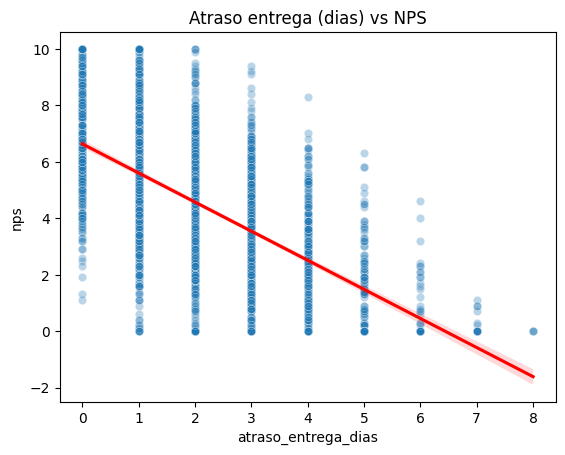

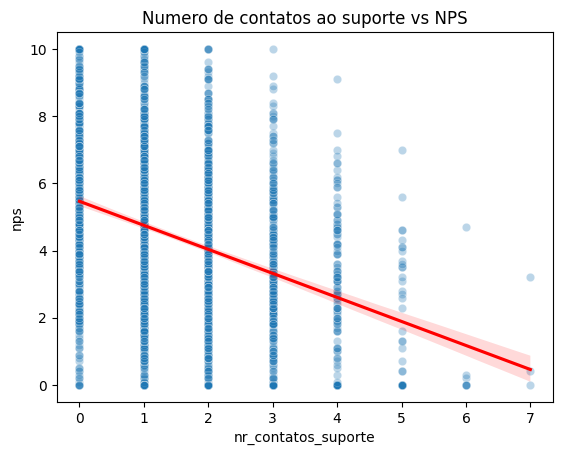

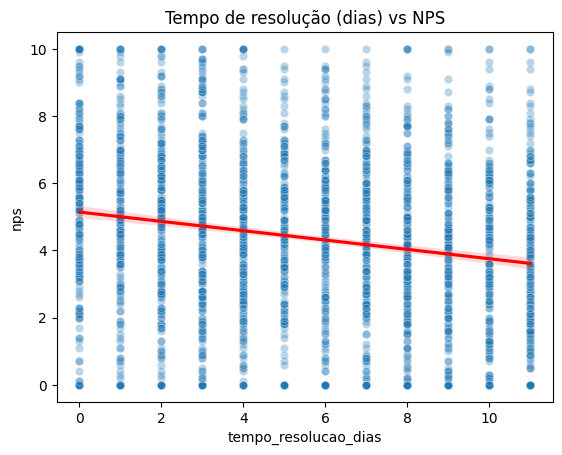

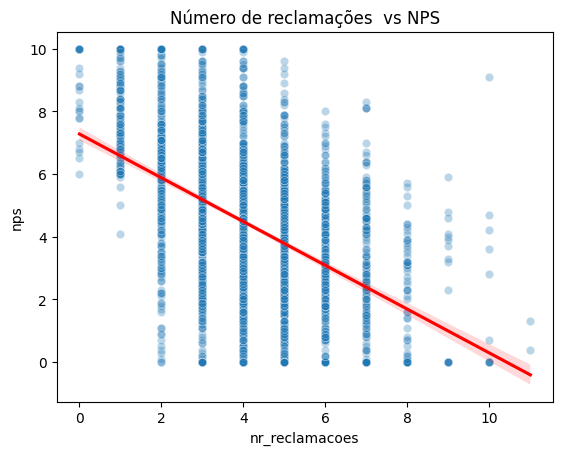

In [ ]:
## agora vamos entender a tendencia da relação direta dessas variaveis com o NPS
# - atraso_entrega_dias
plt.figure()
sns.scatterplot(data=df_nps, x='atraso_entrega_dias', y='nps', alpha=0.3)
sns.regplot(data=df_nps, x='atraso_entrega_dias', y='nps', scatter=False, color='red')
plt.title(f'Atraso entrega (dias) vs NPS')
plt.show()
# - nr_contatos_suporte
plt.figure()
sns.scatterplot(data=df_nps, x='nr_contatos_suporte', y='nps', alpha=0.3)
sns.regplot(data=df_nps, x='nr_contatos_suporte', y='nps', scatter=False, color='red')
plt.title(f'Numero de contatos ao suporte vs NPS')
plt.show()
# - tempo_resolucao_dias
plt.figure()
sns.scatterplot(data=df_nps, x='tempo_resolucao_dias', y='nps', alpha=0.3)
sns.regplot(data=df_nps, x='tempo_resolucao_dias', y='nps', scatter=False, color='red')
plt.title(f'Tempo de resolução (dias) vs NPS')
plt.show()
# - nr_reclamacoes
plt.figure()
sns.scatterplot(data=df_nps, x='nr_reclamacoes', y='nps', alpha=0.3)
sns.regplot(data=df_nps, x='nr_reclamacoes', y='nps', scatter=False, color='red')
plt.title(f'Número de reclamações  vs NPS')
plt.show()

- agora vamos entender o que mais gera detratores

In [ ]:
## ainda utilizando a base que separamos mais cedo, vamos separar detratores de não detratores
detratores = df_nps[df_nps['categoria_nps'] == 'detrator']
nao_detratores = df_nps[df_nps['categoria_nps'] != 'detrator']
## dando foco aos detratores
detratores.describe()

,vl_pedido,qt_itens,vl_desconto,nr_parcelas,tempo_entrega_dias,atraso_entrega_dias,vl_frete,nr_tentativas_entrega,nr_contatos_suporte,tempo_resolucao_dias,nps,recompra_30d,nr_reclamacoes,csat_interno
count,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.0,2109.000000,2109.000000
mean,429.309540,3.483167,29.442684,5.977715,7.994310,2.414889,38.298326,1.997155,1.632053,5.694642,3.651778,0.0,4.442390,2.536036
std,287.091872,1.683531,29.043710,3.155516,3.770449,1.426566,12.037688,0.809685,1.243670,3.440973,1.978905,0.0,1.675848,2.179704
min,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,216.050000,2.000000,8.740000,3.000000,5.000000,1.000000,29.930000,1.000000,1.000000,3.000000,2.200000,0.0,3.000000,0.300000
50%,374.010000,3.000000,20.460000,6.000000,8.000000,2.000000,38.760000,2.000000,1.000000,6.000000,3.900000,0.0,4.000000,2.300000
75%,572.300000,5.000000,40.330000,9.000000,11.000000,3.000000,46.360000,3.000000,2.000000,9.000000,5.300000,0.0,5.000000,4.100000
max,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,6.900000,0.0,11.000000,8.900000


In [ ]:
## dando foco as não detratores
nao_detratores.describe()

,vl_pedido,qt_itens,vl_desconto,nr_parcelas,tempo_entrega_dias,atraso_entrega_dias,vl_frete,nr_tentativas_entrega,nr_contatos_suporte,tempo_resolucao_dias,nps,recompra_30d,nr_reclamacoes,csat_interno
count,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000
mean,460.960435,3.404092,31.379616,6.145780,8.171355,0.959079,37.778440,2.051151,0.913043,4.358056,8.298977,0.557545,2.575448,5.129156
std,302.810821,1.708316,30.173507,3.182762,3.771526,0.873169,12.287389,0.845769,0.959492,3.333541,0.971675,0.497314,1.506843,2.212788
min,33.290000,1.000000,0.350000,1.000000,2.000000,0.000000,4.080000,1.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000
25%,234.125000,2.000000,9.300000,3.000000,5.000000,0.000000,30.005000,1.000000,0.000000,1.500000,7.450000,0.000000,1.000000,3.400000
50%,386.800000,3.000000,23.200000,6.000000,8.000000,1.000000,37.170000,2.000000,1.000000,4.000000,8.100000,1.000000,2.000000,5.400000
75%,614.545000,5.000000,41.870000,9.000000,12.000000,1.000000,45.520000,3.000000,1.500000,7.000000,9.100000,1.000000,3.500000,6.700000
max,1826.220000,6.000000,197.600000,11.000000,14.000000,4.000000,72.450000,3.000000,5.000000,11.000000,10.000000,1.000000,10.000000,10.000000


In [ ]:
## agora vamos separar algumas variaveis que chamaram a atenção para destrinchar a analise
variaveis = [
    'atraso_entrega_dias',
    'nr_contatos_suporte',
    'nr_reclamacoes',
    'tempo_resolucao_dias'
]

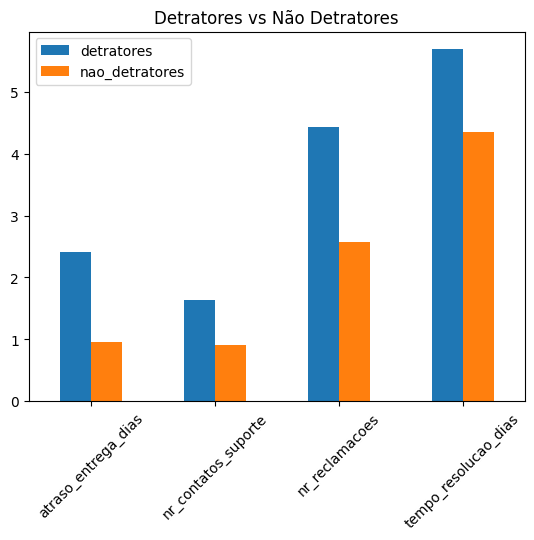

In [ ]:
## comparação direta entre detradores e não detradores
comp = pd.DataFrame({
    'detratores': detratores[variaveis].mean(),
    'nao_detratores': nao_detratores[variaveis].mean()
})

comp.plot(kind='bar')
plt.title('Detratores vs Não Detratores')
plt.xticks(rotation=45)
plt.show()

- agora vamos ver se há algum ponto de ruptura

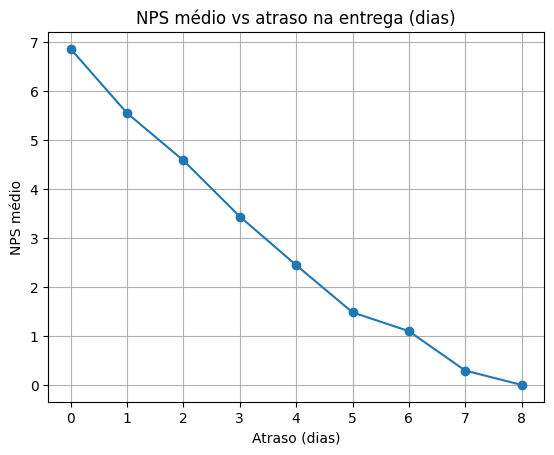

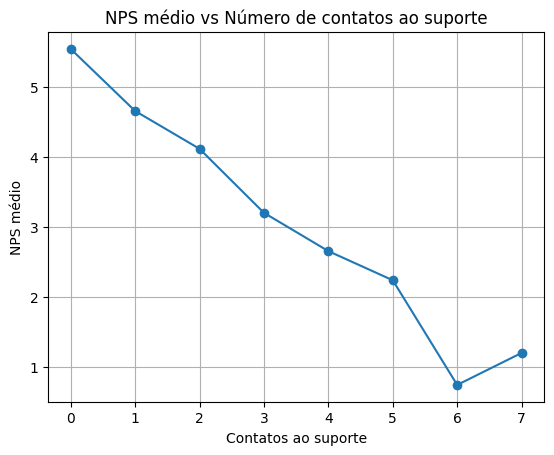

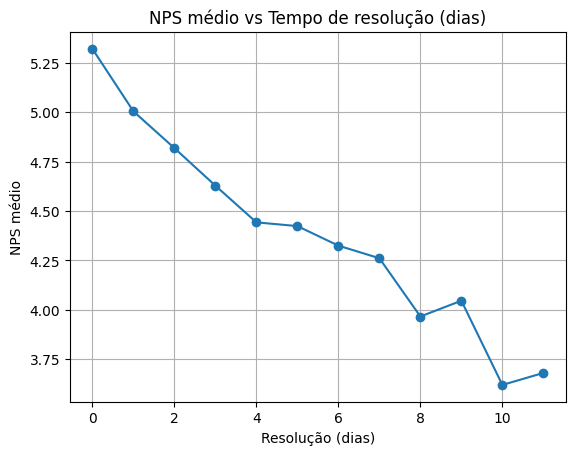

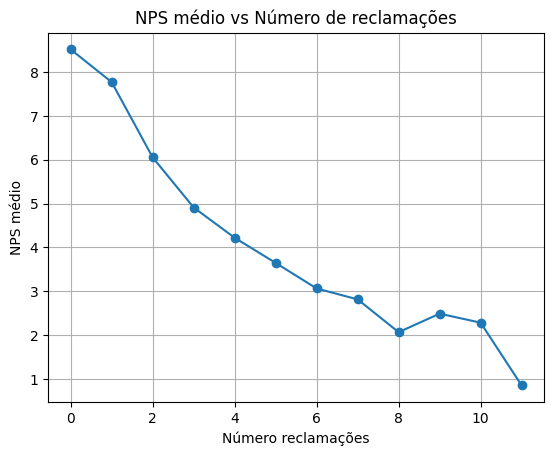

In [ ]:
## utilizando ainda a base que separamos, vamos construir uma curva do NPS para determinadas variaveis
# atraso_entrega_dias
df_nps.groupby('atraso_entrega_dias')['nps'].mean().plot(marker='o')
plt.title('NPS médio vs atraso na entrega (dias)')
plt.xlabel('Atraso (dias)')
plt.ylabel('NPS médio')
plt.grid()
plt.show()
# nr_contatos_suporte
df_nps.groupby('nr_contatos_suporte')['nps'].mean().plot(marker='o')
plt.title('NPS médio vs Número de contatos ao suporte')
plt.xlabel('Contatos ao suporte')
plt.ylabel('NPS médio')
plt.grid()
plt.show()
# tempo_resolucao_dias
df_nps.groupby('tempo_resolucao_dias')['nps'].mean().plot(marker='o')
plt.title('NPS médio vs Tempo de resolução (dias)')
plt.xlabel('Resolução (dias)')
plt.ylabel('NPS médio')
plt.grid()
plt.show()
# nr_reclamacoes
df_nps.groupby('nr_reclamacoes')['nps'].mean().plot(marker='o')
plt.title('NPS médio vs Número de reclamações')
plt.xlabel('Número reclamações')
plt.ylabel('NPS médio')
plt.grid()
plt.show()


/tmp/ipykernel_3475/863598463.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nps['faixa_atraso'] = pd.cut(df_nps['atraso_entrega_dias'], bins=bins, labels=labels)
/tmp/ipykernel_3475/863598463.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_nps.groupby('faixa_atraso')['nps'].mean().plot(kind='bar')


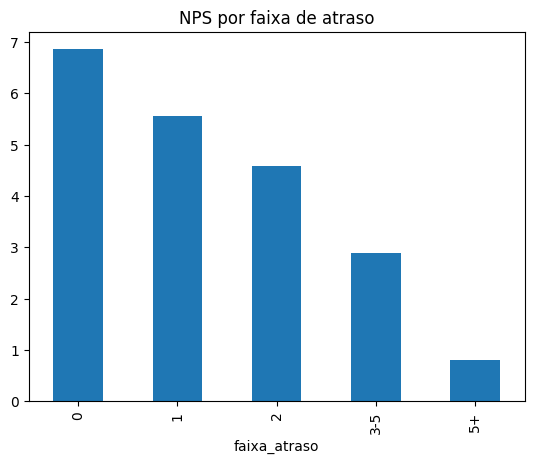

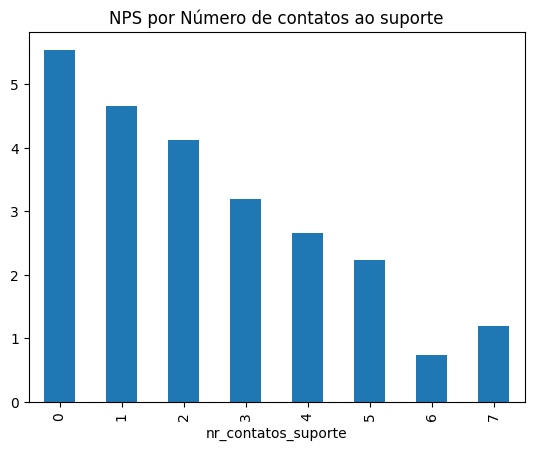

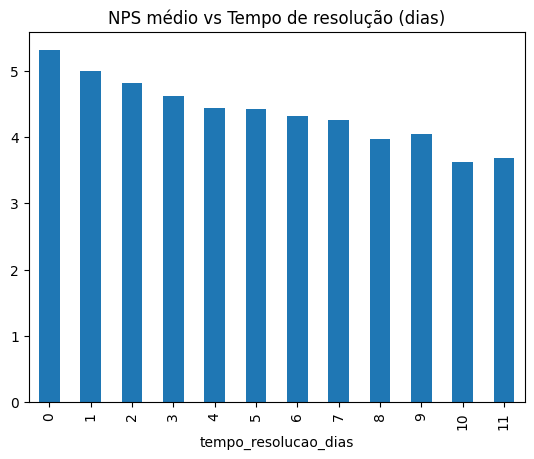

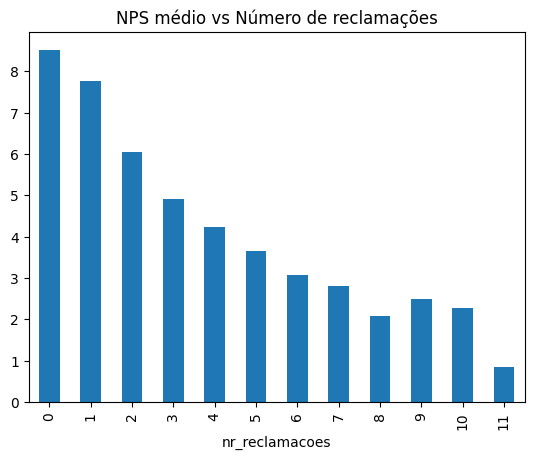

In [ ]:
## agora vamos agrupar por faixas algumas analises
bins = [-1, 0, 1, 2, 5, 10]
labels = ['0', '1', '2', '3-5', '5+']

df_nps['faixa_atraso'] = pd.cut(df_nps['atraso_entrega_dias'], bins=bins, labels=labels)

# atraso_entrega_dias
df_nps.groupby('faixa_atraso')['nps'].mean().plot(kind='bar')
plt.title('NPS por faixa de atraso')
plt.show()

# nr_contatos_suporte
df_nps.groupby('nr_contatos_suporte')['nps'].mean().plot(kind='bar')
plt.title('NPS por Número de contatos ao suporte')
plt.show()

# tempo_resolucao_dias
df_nps.groupby('tempo_resolucao_dias')['nps'].mean().plot(kind='bar')
plt.title('NPS médio vs Tempo de resolução (dias)')
plt.show()

# nr_reclamacoes
df_nps.groupby('nr_reclamacoes')['nps'].mean().plot(kind='bar')
plt.title('NPS médio vs Número de reclamações')
plt.show()

- por fim vamos entener que tipo de cliente tende a ter NPS mais alto ou mais baixo

In [ ]:
## separando colunas relevantes para analise
df_cliente = df[['id_cliente', 'idade_cliente', 'regiao_cliente', 'tempo_relacionamento_cliente_meses', 'nps', 'categoria_nps',
                 'csat_interno', 'recompra_30d', 'atraso_entrega_dias', 'nr_contatos_suporte']]

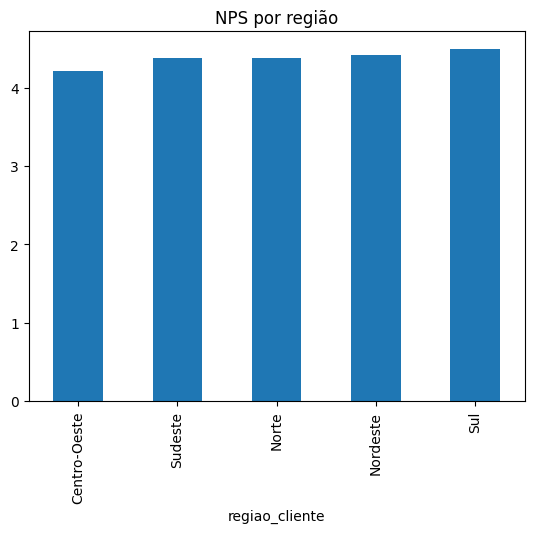

In [ ]:
## analises por perfis de clientes
# região
df_cliente.groupby('regiao_cliente')['nps'].mean().sort_values().plot(kind='bar')
plt.title('NPS por região')
plt.show()

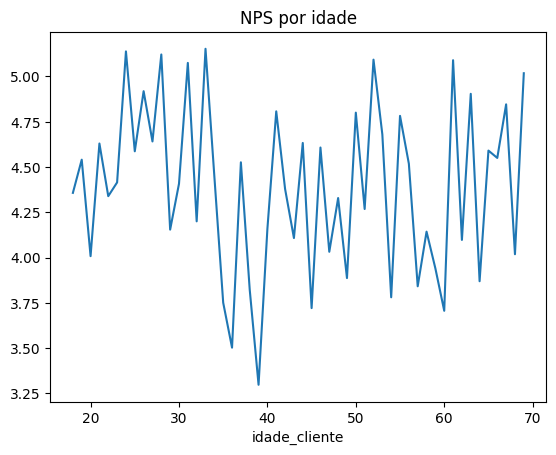

In [ ]:
## analises por perfis de clientes
# idade
df_cliente.groupby('idade_cliente')['nps'].mean().plot()
plt.title('NPS por idade')
plt.show()

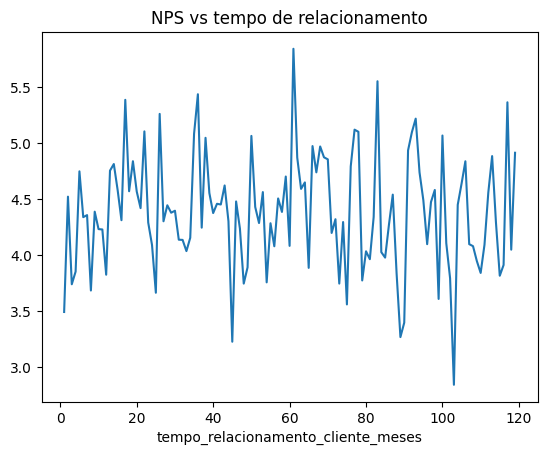

In [ ]:
## analises por perfis de clientes
# tempo de relacionamento (meses)
df_cliente.groupby('tempo_relacionamento_cliente_meses')['nps'].mean().plot()
plt.title('NPS vs tempo de relacionamento')
plt.show()

In [ ]:
df_cliente.groupby('recompra_30d')['categoria_nps'].value_counts(normalize=True)

recompra_30d  categoria_nps
0             detrator         0.924189
              neutro           0.075811
1             promotor         0.504587
              neutro           0.495413
Name: proportion, dtype: float64

In [ ]:
## agora vamos compara a relação de detratores ou promotores com atraso
bins = [-1, 0, 1, 2, 5, 10]
labels = ['0', '1', '2', '3-5', '5+']

df_cliente['faixa_atraso'] = pd.cut(df_cliente['atraso_entrega_dias'], bins=bins, labels=labels)

df_cliente.groupby('faixa_atraso')['categoria_nps'].value_counts(normalize=True)

/tmp/ipykernel_3475/2258171137.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cliente['faixa_atraso'] = pd.cut(df_cliente['atraso_entrega_dias'], bins=bins, labels=labels)
/tmp/ipykernel_3475/2258171137.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cliente.groupby('faixa_atraso')['categoria_nps'].value_counts(normalize=True)


faixa_atraso  categoria_nps
0             detrator         0.516245
              neutro           0.303249
              promotor         0.180505
1             detrator         0.739837
              neutro           0.188618
              promotor         0.071545
2             detrator         0.879257
              neutro           0.100619
              promotor         0.020124
3-5           detrator         0.979144
              neutro           0.017563
              promotor         0.003293
5+            detrator         1.000000
              neutro           0.000000
              promotor         0.000000
Name: proportion, dtype: float64

In [ ]:
## agora vamos compara a relação de detratores ou promotores com a quantidade de contatos ao suporte
df_cliente.groupby('nr_contatos_suporte')['categoria_nps'].value_counts(normalize=True)

nr_contatos_suporte  categoria_nps
0                    detrator         0.707581
                     neutro           0.189531
                     promotor         0.102888
1                    detrator         0.839461
                     neutro           0.116422
                     promotor         0.044118
2                    detrator         0.885938
                     neutro           0.092188
                     promotor         0.021875
3                    detrator         0.933121
                     neutro           0.060510
                     promotor         0.006369
4                    detrator         0.977273
                     neutro           0.015152
                     promotor         0.007576
5                    detrator         0.970588
                     neutro           0.029412
6                    detrator         1.000000
7                    detrator         1.000000
Name: proportion, dtype: float64